#Downloading the Dataset from Kaggle

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emineyetm/fake-news-detection-datasets")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/fake-news-detection-datasets


In [5]:
import pandas as pd

In [6]:
fake_df = pd.read_csv("/kaggle/input/fake-news-detection-datasets/News _dataset/Fake.csv")
real_df = pd.read_csv("/kaggle/input/fake-news-detection-datasets/News _dataset/True.csv")


#Labeling the Datasets

In [8]:
fake_df["label"] = 0  # 0 = Fake
real_df["label"] = 1  # 1 = Real

In [9]:
data = pd.concat([fake_df, real_df], ignore_index=True)

In [10]:
data = data.sample(frac=1).reset_index(drop=True)

In [21]:
data.head()

,title,text,subject,date,label,content
0,WATCH: DIVISIVE FORMER First Lady MICHELLE OBA...,"Michelle Obama is hands-down, the most divisiv...",left-news,"Oct 4, 2017",0,watch divisive former first lady michelle obam...
1,HERE ARE THE FIVE State Department Rules That ...,While Hillary doubles down on her false claim ...,Government News,"May 27, 2016",0,five state department rule hillary violated vi...
2,Here’s Your Handy List Of Lies Lying Liar Mik...,It is widely believed that GOP vice presidenti...,News,"October 5, 2016",0,handy list lie lying liar mike penny told deba...
3,BREAKING: WATCH COPS Shut Down PORTLAND PUNK P...,Portland protesters were doing the usual idiot...,left-news,"Jan 25, 2017",0,breaking watch cop shut portland punk proteste...
4,U.S. condemns threat to ban Venezuela oppositi...,WASHINGTON (Reuters) - The U.S. State Departme...,worldnews,"December 12, 2017",1,condemns threat ban venezuela opposition elect...


#Merging The Fake and Real Datasets

In [13]:
data['content'] = data["title"] + " " + data["text"]

#Importing Necessary Libraries

In [14]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

#Removing stop words and Lemmatizing words

In [15]:
sp = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [18]:
def preprocess(text):
  text = re.sub(r'[^a-zA-Z]', ' ', text)
  tokens = nltk.word_tokenize(text.lower())
  tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in sp and len(word) > 2]
  return ' '.join(tokens)


In [19]:
data['content'] = data['content'].apply(preprocess)

In [20]:
data['content'].head()

,content
0,watch divisive former first lady michelle obam...
1,five state department rule hillary violated vi...
2,handy list lie lying liar mike penny told deba...
3,breaking watch cop shut portland punk proteste...
4,condemns threat ban venezuela opposition elect...


#Encoding Data

In [69]:
X = data['content']
y = data['label']

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

#Train test Split

In [71]:
vec = TfidfVectorizer()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
x_train_vec = vec.fit_transform(X_train)

#Fitting Data

In [81]:
svm = LinearSVC()
svm.fit(x_train_vec, y_train)

LinearSVC()

In [74]:
x_test_vec = vec.transform(X_test)

In [82]:
y_pred = svm.predict(x_test_vec)

#Evaluating the model accuracy

In [83]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy: 0.9939
F1 Score: 0.9935


#Bonus Task Creating the WordCloud

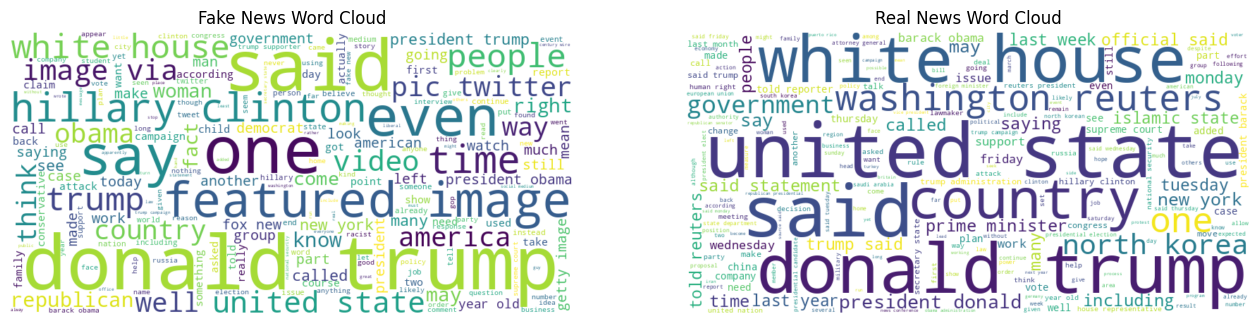

In [84]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Separate fake and real news
fake_text = " ".join(data[data['label'] == 0]['content'])
real_text = " ".join(data[data['label'] == 1]['content'])

# Creating word clouds
fake_wc = WordCloud(width=800, height=400, background_color='white').generate(fake_text)
real_wc = WordCloud(width=800, height=400, background_color='white').generate(real_text)

# Plotting
plt.figure(figsize=(16,8))

plt.subplot(1, 2, 1)
plt.imshow(fake_wc, interpolation='bilinear')
plt.title("Fake News Word Cloud")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(real_wc, interpolation='bilinear')
plt.title("Real News Word Cloud")
plt.axis('off')

plt.show()
